# 🦷 Análisis Exploratorio de Datos — Predicción Dentaduras

Este notebook realiza un **EDA completo** sobre el dataset de imágenes de dentaduras.

**Clases:**
- `0` → Dentadura / Prótesis dental
- `1` → Diente sano
- `2` → Caries
- `3` → Otro / Fondo

**Secciones:**
1. Configuración y Carga de Datos
2. Estructura del Dataset
3. Distribución de Etiquetas
4. Propiedades de Imágenes
5. Brillo y Contraste por Clase
6. Canales de Color (RGB)
7. Muestras Visuales por Clase
8. Detección de Duplicados y Calidad
9. Análisis de Correlaciones
10. Outliers y Anomalías
11. Resumen Ejecutivo


---
## 1. Configuración y Carga de Datos

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from PIL import Image
from scipy import stats
from scipy.stats import chi2_contingency
import io
import hashlib
import warnings
warnings.filterwarnings('ignore')

# ─── Estilo global ───────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#1e1e2e',
    'axes.facecolor':   '#181825',
    'axes.edgecolor':   '#45475a',
    'axes.labelcolor':  '#cdd6f4',
    'xtick.color':      '#cdd6f4',
    'ytick.color':      '#cdd6f4',
    'text.color':       '#cdd6f4',
    'grid.color':       '#313244',
    'grid.alpha':        0.5,
    'axes.grid':         True,
    'font.family':      'DejaVu Sans',
    'font.size':         11,
})

# ─── Colores y etiquetas de clase ─────────────────────────────────────────
CLASS_COLORS  = ['#89b4fa', '#a6e3a1', '#fab387', '#f38ba8']
CLASS_LABELS  = ['Clase 0\n(Prótesis)', 'Clase 1\n(Sano)', 'Clase 2\n(Caries)', 'Clase 3\n(Otro)']
CLASS_NAMES   = ['Prótesis', 'Sano', 'Caries', 'Otro']

# ─── Helpers ──────────────────────────────────────────────────────────────
def bytes_to_pil(b):
    """Convierte bytes a imagen PIL."""
    if isinstance(b, dict):
        b = b.get('bytes', b)
    return Image.open(io.BytesIO(b)).convert('RGB')

def compute_image_stats(row):
    """Extrae estadísticas de una imagen: tamaño, brillo, contraste, color."""
    try:
        img  = bytes_to_pil(row['image'])
        arr  = np.array(img, dtype=np.float32)
        gray = arr.mean(axis=2)
        return {
            'width':      img.width,
            'height':     img.height,
            'aspect':     round(img.width / img.height, 3),
            'bytes_size': len(row['image']['bytes'] if isinstance(row['image'], dict) else row['image']),
            'brightness': round(gray.mean(), 3),
            'contrast':   round(gray.std(), 3),
            'mean_r':     round(arr[:,:,0].mean(), 3),
            'mean_g':     round(arr[:,:,1].mean(), 3),
            'mean_b':     round(arr[:,:,2].mean(), 3),
            'std_r':      round(arr[:,:,0].std(), 3),
            'std_g':      round(arr[:,:,1].std(), 3),
            'std_b':      round(arr[:,:,2].std(), 3),
            'md5':        hashlib.md5(row['image']['bytes'] if isinstance(row['image'], dict) else row['image']).hexdigest(),
        }
    except Exception:
        return None

# ─── Carga de datos ───────────────────────────────────────────────────────
print('Cargando datos...')
df_train = pd.read_parquet('train-00000-of-00001.parquet')
df_test  = pd.read_parquet('test-00000-of-00001.parquet')
print(f'  Train: {df_train.shape}  |  Test: {df_test.shape}')
print('✅ Datos cargados.')

Cargando datos...
  Train: (823, 2)  |  Test: (206, 2)
✅ Datos cargados.


---
## 2. Estructura del Dataset

In [3]:
from IPython.display import display

print('=== COLUMNAS ===')
for df, name in [(df_train, 'Train'), (df_test, 'Test')]:
    print(f'\n{name}:')
    print(df.dtypes)
    print(f'Nulos: {df.isnull().sum().to_dict()}')

# Tabla resumen
summary = pd.DataFrame({
    'Split':      ['Train', 'Test'],
    'Filas':      [len(df_train), len(df_test)],
    '% del total':[round(100*len(df_train)/(len(df_train)+len(df_test)),1),
                   round(100*len(df_test) /(len(df_train)+len(df_test)),1)],
    'Clases únicas':[df_train['label'].nunique() if 'label' in df_train.columns else '-',
                     df_test ['label'].nunique() if 'label' in df_test .columns else '-'],
    'Nulos totales':[df_train.isnull().sum().sum(), df_test.isnull().sum().sum()],
})
display(summary)

=== COLUMNAS ===

Train:
image    object
label     int64
dtype: object
Nulos: {'image': 0, 'label': 0}

Test:
image    object
label     int64
dtype: object
Nulos: {'image': 0, 'label': 0}


,Split,Filas,% del total,Clases únicas,Nulos totales
0,Train,823,80.0,4,0
1,Test,206,20.0,4,0


---
## 3. Distribución de Etiquetas

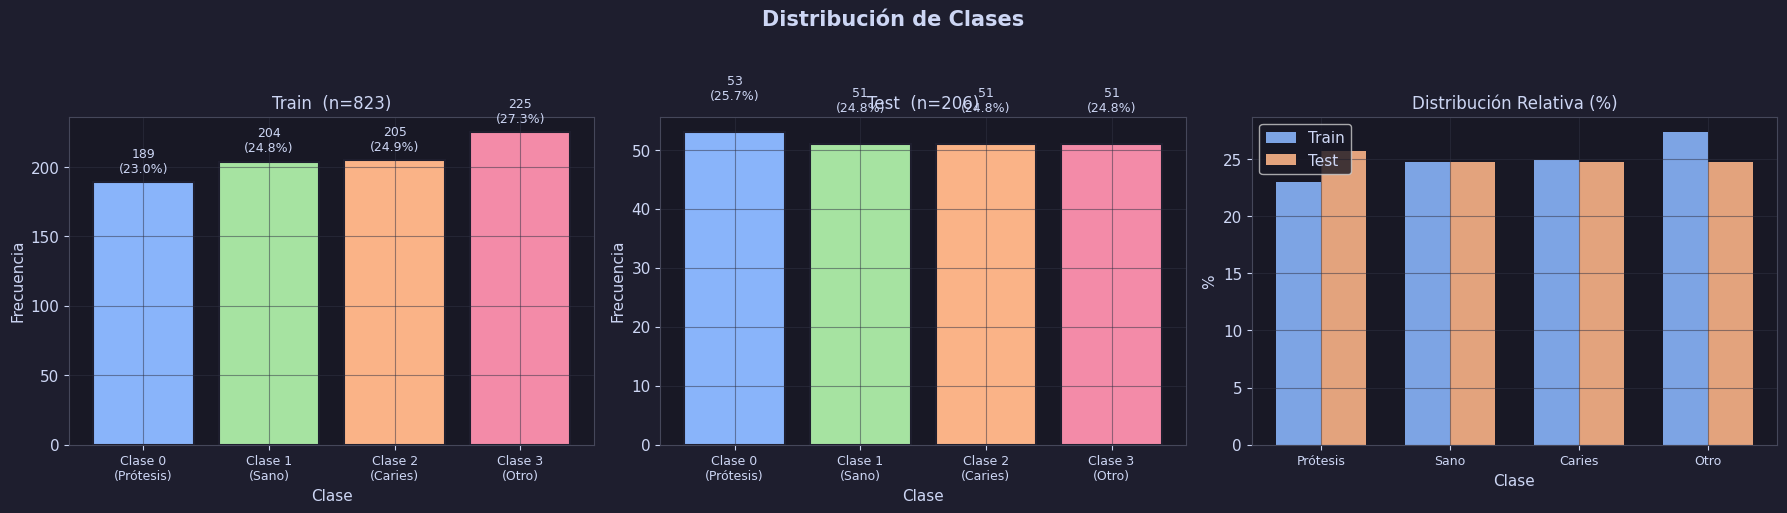


✅ Chi-cuadrado (Train): χ²=3.18, p-valor=0.3644
→ Desbalance de clases: ✅ NO significativo


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Distribución de Clases', fontsize=15, fontweight='bold', color='#cdd6f4', y=1.02)

for ax, (df, name) in zip(axes[:2], [(df_train, 'Train'), (df_test, 'Test')]):
    counts = df['label'].value_counts().sort_index()
    bars = ax.bar(counts.index, counts.values, color=CLASS_COLORS, edgecolor='#1e1e2e', linewidth=1.5)
    ax.set_title(f'{name}  (n={len(df):,})', fontsize=12, color='#cdd6f4')
    ax.set_xlabel('Clase'); ax.set_ylabel('Frecuencia')
    ax.set_xticks(range(4)); ax.set_xticklabels(CLASS_LABELS, fontsize=9)
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                f'{val}\n({val/len(df)*100:.1f}%)', ha='center', va='bottom', fontsize=9, color='#cdd6f4')

# Distribución relativa comparada
ax = axes[2]
x = np.arange(4); width = 0.35
train_pct = [df_train['label'].value_counts().sort_index().get(i, 0)/len(df_train)*100 for i in range(4)]
test_pct  = [df_test ['label'].value_counts().sort_index().get(i, 0)/len(df_test )*100 for i in range(4)]
ax.bar(x - width/2, train_pct, width, color='#89b4fa', label='Train', alpha=0.9)
ax.bar(x + width/2, test_pct,  width, color='#fab387', label='Test',  alpha=0.9)
ax.set_title('Distribución Relativa (%)', fontsize=12, color='#cdd6f4')
ax.set_xlabel('Clase'); ax.set_ylabel('%')
ax.set_xticks(x); ax.set_xticklabels(CLASS_NAMES, fontsize=9)
ax.legend()
plt.tight_layout(); plt.show()

# Chi-cuadrado
observed = pd.crosstab(df_train['label'], columns='count')['count'].values
chi2, p_chi = stats.chisquare(observed)
print(f'\n✅ Chi-cuadrado (Train): χ²={chi2:.2f}, p-valor={p_chi:.4f}')
print('→ Desbalance de clases:',
      '⚠️ SÍ (p<0.05)' if p_chi < 0.05 else '✅ NO significativo')

---
## 4. Propiedades de Imágenes
> ⏱ Este paso tarda ~2-4 minutos dependiendo del hardware.

In [5]:
print('Extrayendo propiedades de imágenes... (puede tardar unos minutos)')

train_stats = df_train.apply(compute_image_stats, axis=1).dropna()
df_train_stats = pd.DataFrame(list(train_stats))
df_train_stats['label'] = df_train['label'].values[:len(df_train_stats)]
if 'path' in df_train.columns:
    df_train_stats['path'] = df_train['path'].values[:len(df_train_stats)]

test_stats = df_test.apply(compute_image_stats, axis=1).dropna()
df_test_stats = pd.DataFrame(list(test_stats))
if 'label' in df_test.columns:
    df_test_stats['label'] = df_test['label'].values[:len(df_test_stats)]
if 'path' in df_test.columns:
    df_test_stats['path'] = df_test['path'].values[:len(df_test_stats)]

print(f'✅ Train stats: {len(df_train_stats)} imágenes  |  Test stats: {len(df_test_stats)} imágenes')
print('\n📊 Estadísticas descriptivas (Train):')
display(df_train_stats[['width','height','aspect','bytes_size','brightness','contrast']].describe().round(2))

Extrayendo propiedades de imágenes... (puede tardar unos minutos)
✅ Train stats: 823 imágenes  |  Test stats: 206 imágenes

📊 Estadísticas descriptivas (Train):


,width,height,aspect,bytes_size,brightness,contrast
count,823.00,823.00,823.00,823.00,823.00,823.00
mean,1583.88,854.61,1.86,148430.49,126.15,54.63
std,1345.05,725.77,0.03,136763.40,4.48,3.04
min,128.00,76.00,1.47,2732.00,108.37,50.84
25%,142.00,76.00,1.85,3177.50,123.79,52.60
50%,2840.00,1532.00,1.85,248338.00,125.75,54.77
75%,2840.00,1532.00,1.87,276379.00,129.65,55.93
max,2840.00,1532.00,1.87,377352.00,157.24,88.10


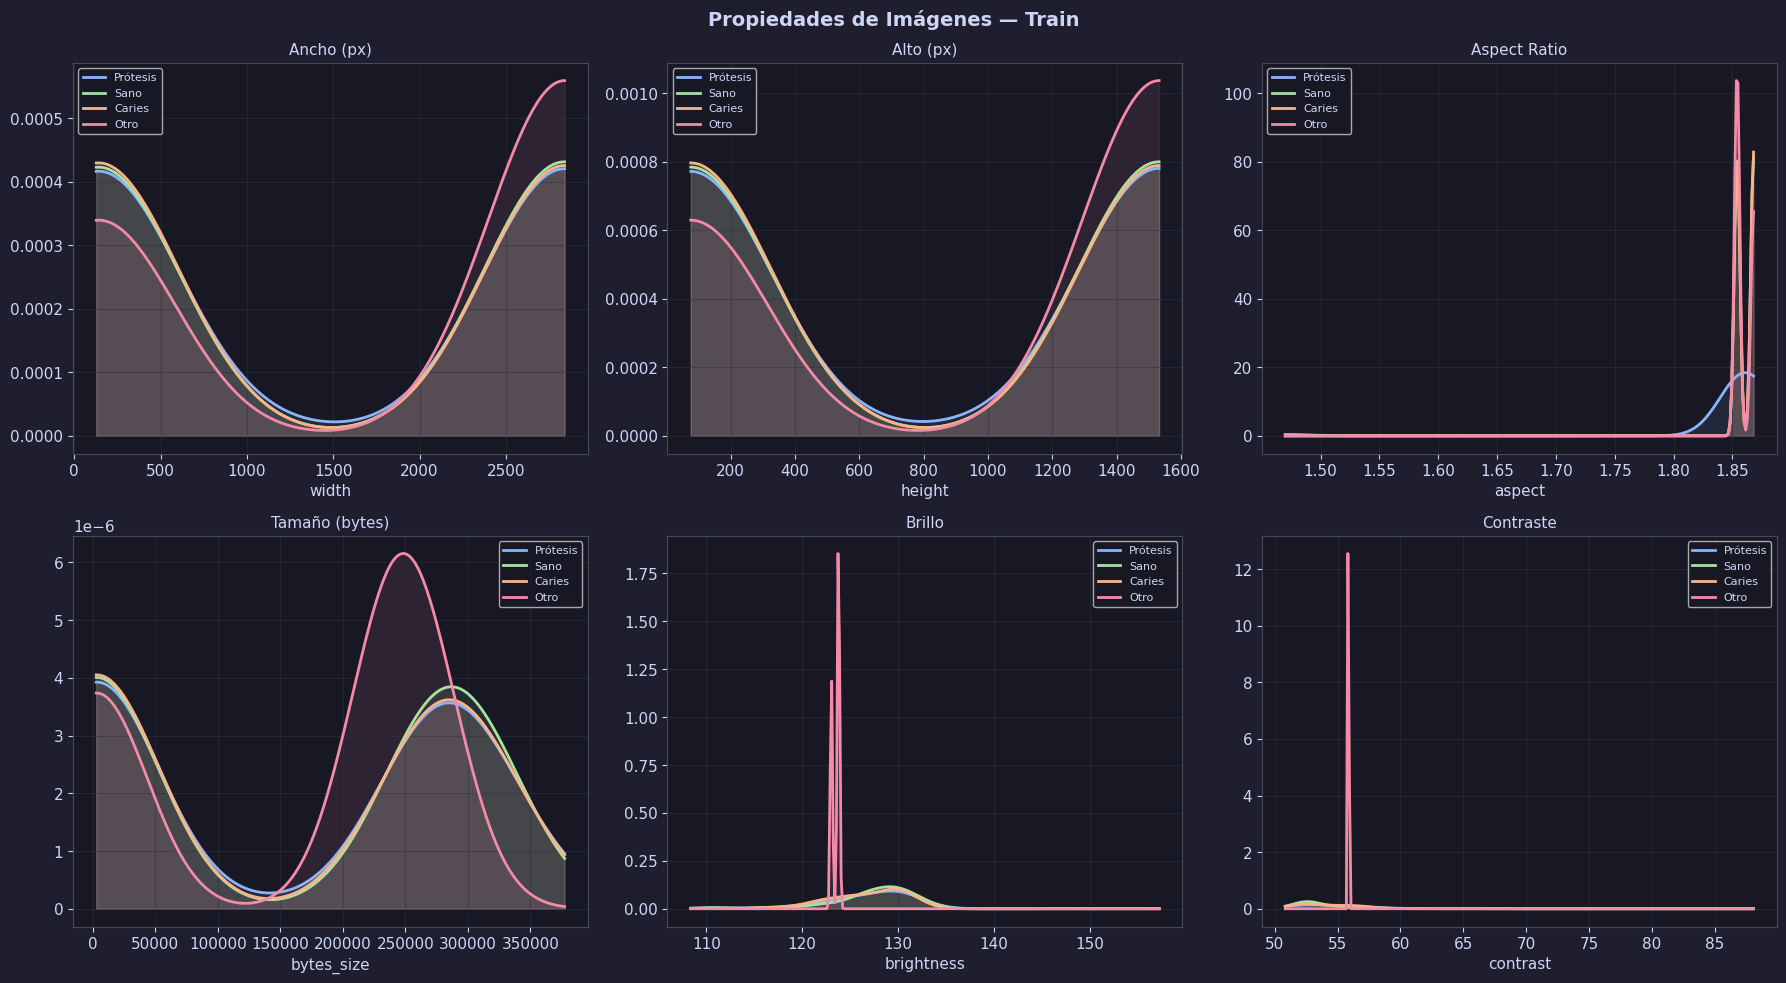

In [6]:
# ─── Distribuciones de propiedades geométricas ───────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Propiedades de Imágenes — Train', fontsize=14, fontweight='bold', color='#cdd6f4')

props = ['width', 'height', 'aspect', 'bytes_size', 'brightness', 'contrast']
titles = ['Ancho (px)', 'Alto (px)', 'Aspect Ratio', 'Tamaño (bytes)', 'Brillo', 'Contraste']

for ax, prop, title in zip(axes.flatten(), props, titles):
    for cls in range(4):
        data = df_train_stats[df_train_stats['label'] == cls][prop].values
        if len(data) > 1:
            kde = stats.gaussian_kde(data)
            xr = np.linspace(df_train_stats[prop].min(), df_train_stats[prop].max(), 300)
            ax.plot(xr, kde(xr), color=CLASS_COLORS[cls], label=CLASS_NAMES[cls], linewidth=2)
            ax.fill_between(xr, kde(xr), alpha=0.1, color=CLASS_COLORS[cls])
    ax.set_title(title, fontsize=11, color='#cdd6f4')
    ax.set_xlabel(prop)
    ax.legend(fontsize=8)

plt.tight_layout(); plt.show()

---
## 5. Brillo y Contraste por Clase

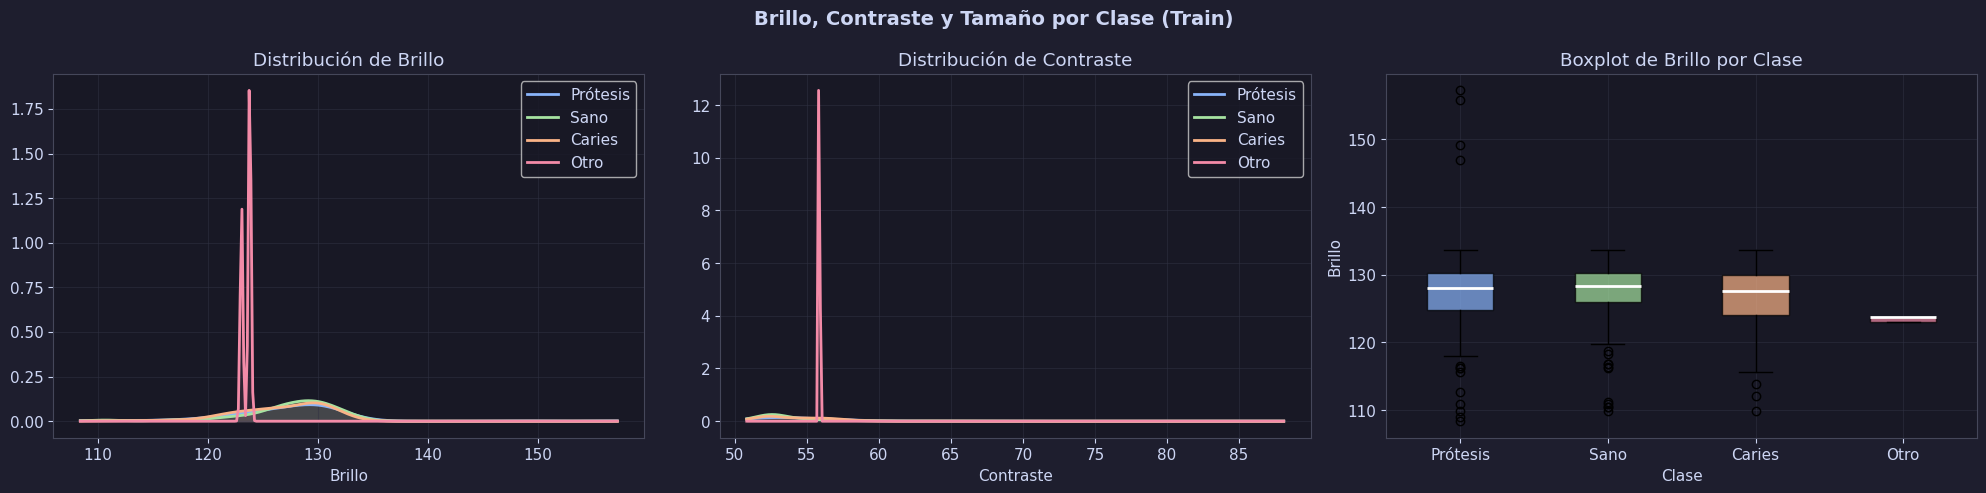


📊 Estadísticas de brillo y contraste por clase:


brightness         contrast            mean_r            mean_g        \
             mean   std       mean   std        mean   std        mean   std   
label                                                                          
0      127.309998  5.97  54.720001  5.07  127.320000  6.00  127.309998  5.96   
1      127.419998  4.41  53.680000  2.41  127.419998  4.41  127.419998  4.41   
2      126.730003  4.18  54.160000  2.25  126.730003  4.18  126.730003  4.18   
3      123.510002  0.36  55.860001  0.05  123.510002  0.36  123.510002  0.36   

           mean_b        
             mean   std  
label                    
0      127.300003  5.95  
1      127.419998  4.41  
2      126.730003  4.18  
3      123.510002  0.36

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle('Brillo, Contraste y Tamaño por Clase (Train)', fontsize=14, fontweight='bold', color='#cdd6f4')

# KDE brillo
for cls in range(4):
    s = df_train_stats[df_train_stats['label'] == cls]
    kde_b = stats.gaussian_kde(s['brightness'].values)
    bx = np.linspace(df_train_stats['brightness'].min(), df_train_stats['brightness'].max(), 300)
    axes[0].plot(bx, kde_b(bx), color=CLASS_COLORS[cls], label=CLASS_NAMES[cls], linewidth=2)
    axes[0].fill_between(bx, kde_b(bx), alpha=0.1, color=CLASS_COLORS[cls])
axes[0].set_title('Distribución de Brillo'); axes[0].set_xlabel('Brillo'); axes[0].legend()

# KDE contraste
for cls in range(4):
    s = df_train_stats[df_train_stats['label'] == cls]
    kde_c = stats.gaussian_kde(s['contrast'].values)
    cx = np.linspace(df_train_stats['contrast'].min(), df_train_stats['contrast'].max(), 300)
    axes[1].plot(cx, kde_c(cx), color=CLASS_COLORS[cls], label=CLASS_NAMES[cls], linewidth=2)
    axes[1].fill_between(cx, kde_c(cx), alpha=0.1, color=CLASS_COLORS[cls])
axes[1].set_title('Distribución de Contraste'); axes[1].set_xlabel('Contraste'); axes[1].legend()

# Box-plot brillo
data_box = [df_train_stats[df_train_stats['label'] == cls]['brightness'].values for cls in range(4)]
bp = axes[2].boxplot(data_box, patch_artist=True, medianprops=dict(color='white', linewidth=2))
for patch, color in zip(bp['boxes'], CLASS_COLORS):
    patch.set_facecolor(color); patch.set_alpha(0.7)
axes[2].set_title('Boxplot de Brillo por Clase')
axes[2].set_xticklabels(CLASS_NAMES)
axes[2].set_xlabel('Clase'); axes[2].set_ylabel('Brillo')

plt.tight_layout(); plt.show()

print('\n📊 Estadísticas de brillo y contraste por clase:')
display(df_train_stats.groupby('label')[['brightness','contrast','mean_r','mean_g','mean_b']].agg(['mean','std']).round(2))

---
## 6. Análisis de Canales de Color (RGB)

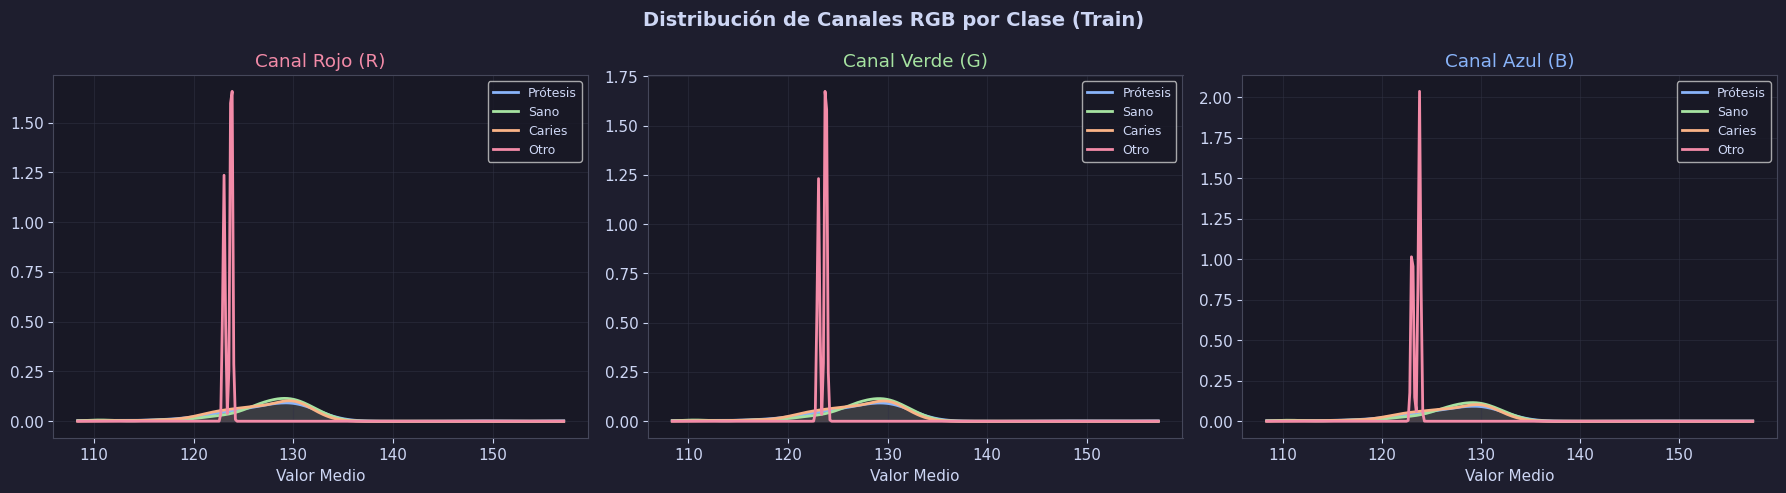

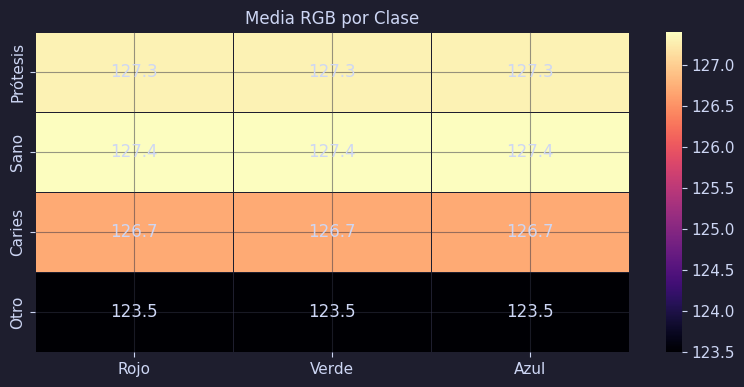

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Distribución de Canales RGB por Clase (Train)', fontsize=14, fontweight='bold', color='#cdd6f4')

channel_colors = ['#f38ba8', '#a6e3a1', '#89b4fa']  # R, G, B
channels = ['mean_r', 'mean_g', 'mean_b']
ch_names  = ['Canal Rojo (R)', 'Canal Verde (G)', 'Canal Azul (B)']

for ax, ch, ch_name, ch_col in zip(axes, channels, ch_names, channel_colors):
    for cls in range(4):
        s = df_train_stats[df_train_stats['label'] == cls][ch].values
        kde = stats.gaussian_kde(s)
        xr = np.linspace(df_train_stats[ch].min(), df_train_stats[ch].max(), 300)
        ax.plot(xr, kde(xr), color=CLASS_COLORS[cls], label=CLASS_NAMES[cls], linewidth=2)
        ax.fill_between(xr, kde(xr), alpha=0.08, color=CLASS_COLORS[cls])
    ax.set_title(ch_name, color=ch_col)
    ax.set_xlabel('Valor Medio'); ax.legend(fontsize=9)

plt.tight_layout(); plt.show()

# Heatmap de medias RGB por clase
fig, ax = plt.subplots(figsize=(8, 4))
rgb_means = df_train_stats.groupby('label')[['mean_r','mean_g','mean_b']].mean().round(1)
rgb_means.index = CLASS_NAMES
rgb_means.columns = ['Rojo', 'Verde', 'Azul']
sns.heatmap(rgb_means, annot=True, fmt='.1f', cmap='magma', ax=ax,
            linewidths=0.5, linecolor='#1e1e2e',
            annot_kws={'color': '#cdd6f4', 'size': 12})
ax.set_title('Media RGB por Clase', fontsize=12, color='#cdd6f4')
ax.tick_params(colors='#cdd6f4')
plt.tight_layout(); plt.show()

---
## 7. Muestras Visuales por Clase
> Visualización de imágenes representativas de cada clase.

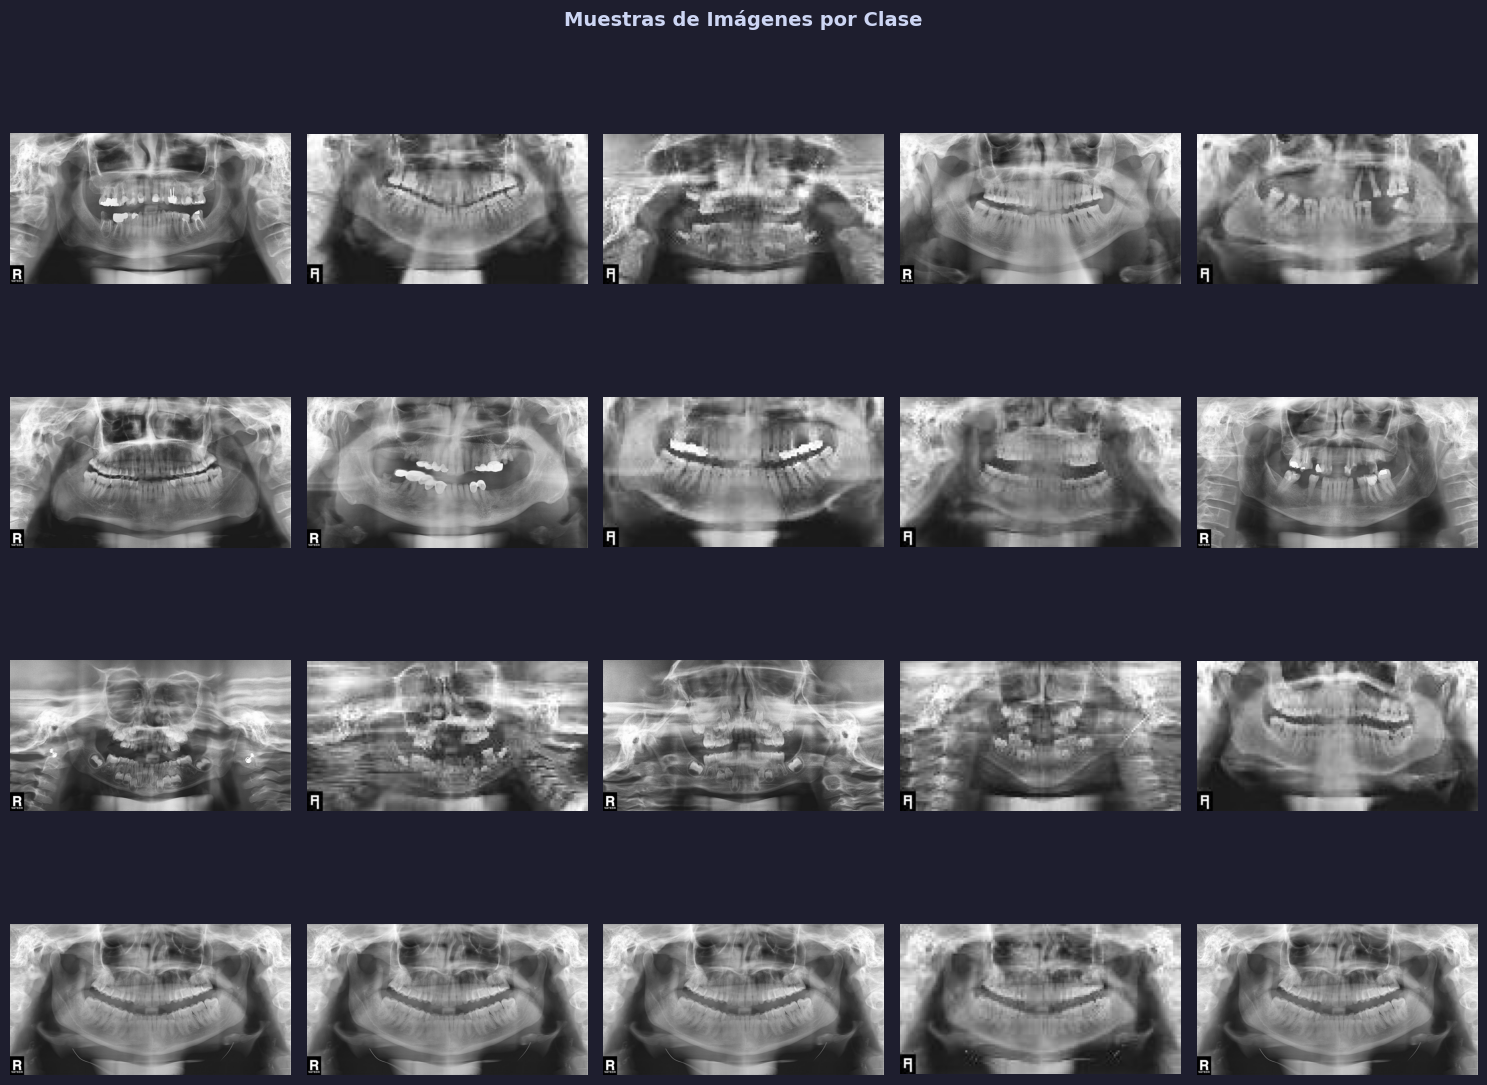

In [9]:
N_SAMPLES = 5  # imágenes por clase

fig, axes = plt.subplots(4, N_SAMPLES, figsize=(N_SAMPLES * 3, 4 * 3))
fig.suptitle('Muestras de Imágenes por Clase', fontsize=14, fontweight='bold', color='#cdd6f4')

for cls in range(4):
    subset = df_train[df_train['label'] == cls]
    samples = subset.sample(min(N_SAMPLES, len(subset)), random_state=42)
    for j, (_, row) in enumerate(samples.iterrows()):
        ax = axes[cls][j]
        try:
            img = bytes_to_pil(row['image'])
            ax.imshow(img)
        except Exception:
            ax.text(0.5, 0.5, 'Error', ha='center', va='center', transform=ax.transAxes)
        ax.axis('off')
        if j == 0:
            ax.set_ylabel(CLASS_NAMES[cls], fontsize=11, color=CLASS_COLORS[cls],
                          rotation=90, labelpad=10)

plt.tight_layout(); plt.show()

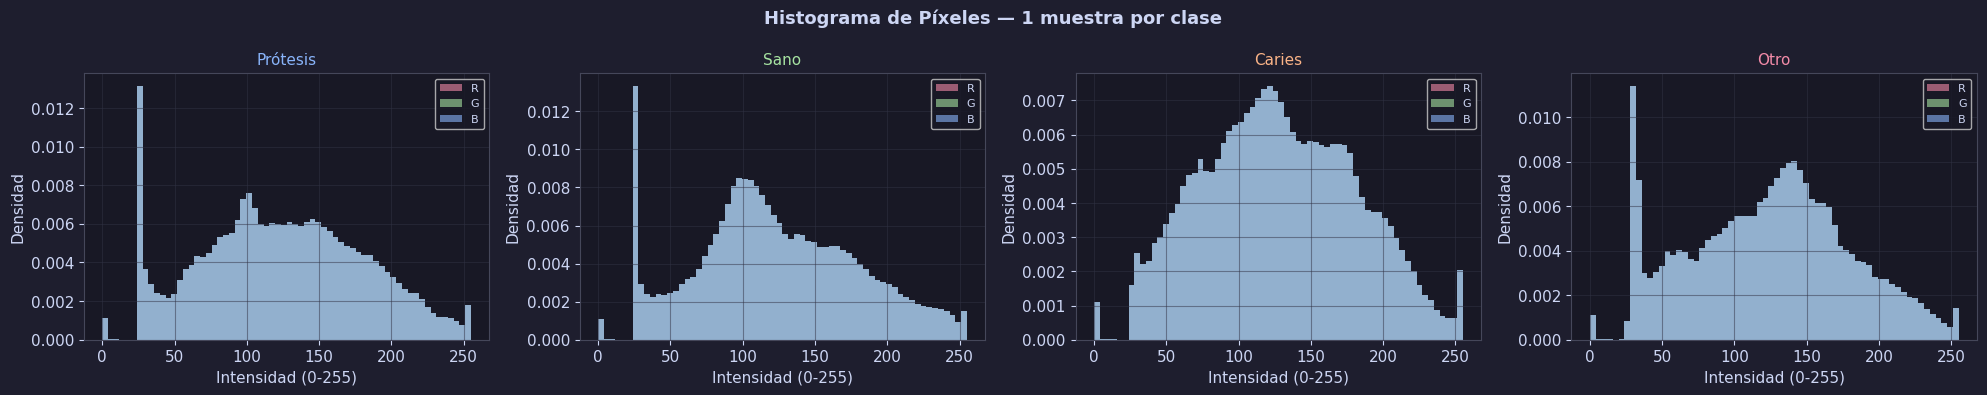

In [10]:
# ─── Histogramas de píxeles por clase ─────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
fig.suptitle('Histograma de Píxeles — 1 muestra por clase', fontsize=13, fontweight='bold', color='#cdd6f4')

for cls in range(4):
    subset = df_train[df_train['label'] == cls]
    row = subset.sample(1, random_state=42).iloc[0]
    img = bytes_to_pil(row['image'])
    arr = np.array(img)
    ax = axes[cls]
    ax.hist(arr[:,:,0].flatten(), bins=64, color='#f38ba8', alpha=0.6, label='R', density=True)
    ax.hist(arr[:,:,1].flatten(), bins=64, color='#a6e3a1', alpha=0.6, label='G', density=True)
    ax.hist(arr[:,:,2].flatten(), bins=64, color='#89b4fa', alpha=0.6, label='B', density=True)
    ax.set_title(f'{CLASS_NAMES[cls]}', color=CLASS_COLORS[cls], fontsize=11)
    ax.set_xlabel('Intensidad (0-255)'); ax.set_ylabel('Densidad')
    ax.legend(fontsize=8)

plt.tight_layout(); plt.show()

---
## 8. Detección de Duplicados y Calidad de Datos

In [11]:
# ─── Duplicados por MD5 ───────────────────────────────────────────────────
print('=== DUPLICADOS POR HASH MD5 ===')
dup_md5_train = df_train_stats[df_train_stats.duplicated(subset='md5', keep=False)]
dup_md5_test  = df_test_stats [df_test_stats .duplicated(subset='md5', keep=False)]
print(f'Train: {len(dup_md5_train)} registros con MD5 duplicado ({len(dup_md5_train)/len(df_train_stats)*100:.1f}%)')
print(f'Test : {len(dup_md5_test )} registros con MD5 duplicado ({len(dup_md5_test )/len(df_test_stats )*100:.1f}%)')

print('\n  Duplicados por clase (Train):')
display(dup_md5_train.groupby('label').size().reset_index(name='n_duplicados'))

# ─── Leakage Train→Test ───────────────────────────────────────────────────
print('\n=== DATA LEAKAGE TRAIN → TEST ===')
leaked = set(df_train_stats['md5']) & set(df_test_stats['md5'])
print(f'Imágenes idénticas (mismo MD5) en Train y Test: {len(leaked)}')
if len(leaked) == 0:
    print('  ✅ No hay data leakage entre train y test.')
else:
    print('  ⚠️  ALERTA: Existen imágenes idénticas en train y test!')

# ─── Paths duplicados ─────────────────────────────────────────────────────
if 'path' in df_train_stats.columns:
    print('\n=== DUPLICADOS POR PATH ===')
    dup_paths = df_train_stats['path'].value_counts()
    dup_paths = dup_paths[dup_paths > 1]
    print(f'Paths con más de 1 aparición: {len(dup_paths)}')
    print(f'Imágenes en esos paths: {dup_paths.sum()}')

=== DUPLICADOS POR HASH MD5 ===
Train: 574 registros con MD5 duplicado (69.7%)
Test : 80 registros con MD5 duplicado (38.8%)

  Duplicados por clase (Train):


,label,n_duplicados
0,0,138
1,1,68
2,2,143
3,3,225



=== DATA LEAKAGE TRAIN → TEST ===
Imágenes idénticas (mismo MD5) en Train y Test: 90
  ⚠️  ALERTA: Existen imágenes idénticas en train y test!


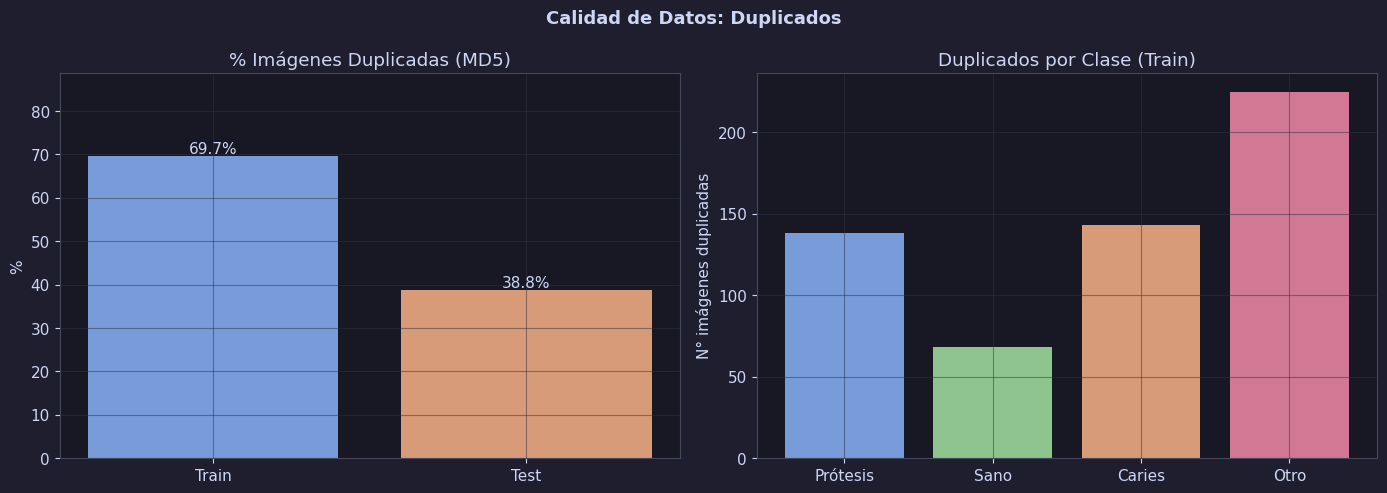

In [12]:
# ─── Visualización de duplicados ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Calidad de Datos: Duplicados', fontsize=13, fontweight='bold', color='#cdd6f4')

# % duplicados por split
ax = axes[0]
splits = ['Train', 'Test']
dup_pct = [
    len(dup_md5_train) / len(df_train_stats) * 100,
    len(dup_md5_test)  / len(df_test_stats)  * 100,
]
bars = ax.bar(splits, dup_pct, color=['#89b4fa', '#fab387'], alpha=0.85)
for bar, v in zip(bars, dup_pct):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{v:.1f}%', ha='center', fontsize=11, color='#cdd6f4')
ax.set_title('% Imágenes Duplicadas (MD5)', color='#cdd6f4')
ax.set_ylabel('%'); ax.set_ylim(0, max(dup_pct) * 1.2 + 5)

# Duplicados por clase (Train)
ax = axes[1]
if len(dup_md5_train) > 0:
    dup_by_class = dup_md5_train.groupby('label').size()
    ax.bar(dup_by_class.index, dup_by_class.values,
           color=[CLASS_COLORS[i] for i in dup_by_class.index], alpha=0.85)
    ax.set_xticks(range(4)); ax.set_xticklabels(CLASS_NAMES)
ax.set_title('Duplicados por Clase (Train)', color='#cdd6f4')
ax.set_ylabel('N° imágenes duplicadas')

plt.tight_layout(); plt.show()

---
## 9. Análisis de Correlaciones

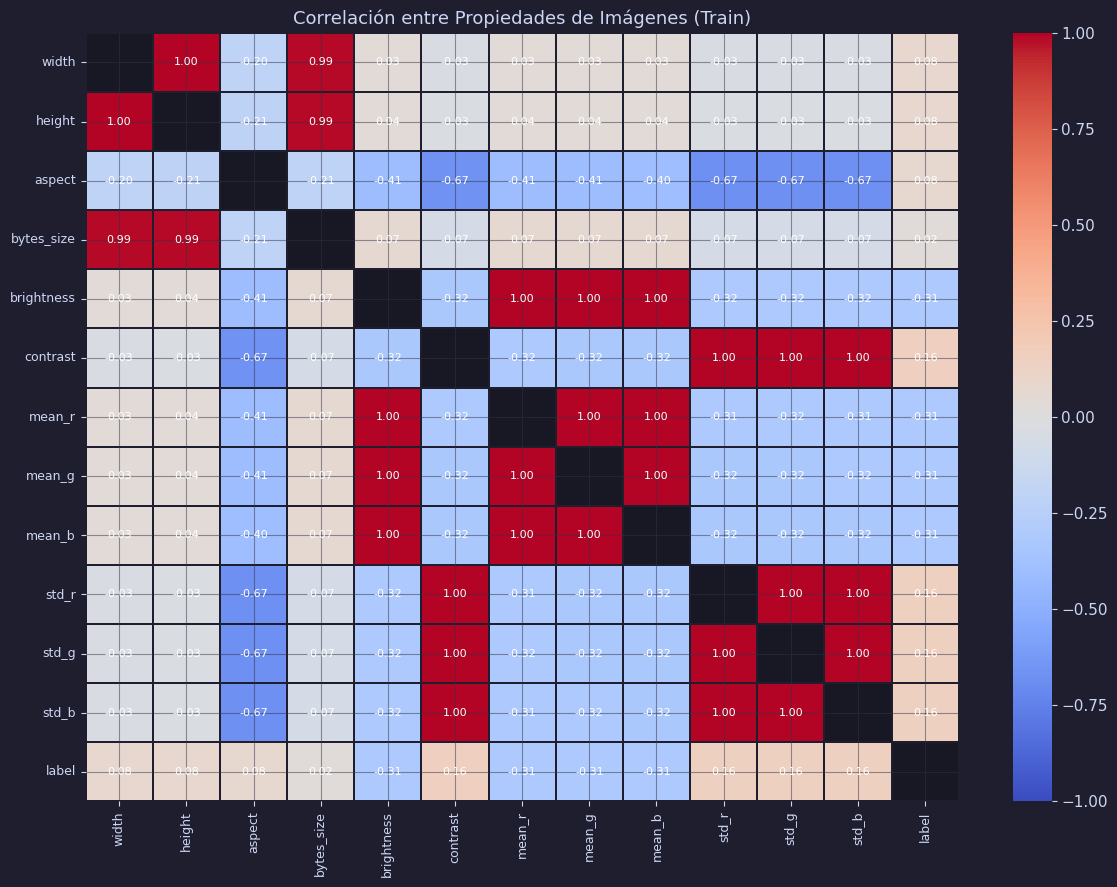


📊 Correlación (|r|) con la etiqueta:
mean_b        0.313
mean_g        0.313
brightness    0.313
mean_r        0.313
contrast      0.157
std_g         0.156
std_r         0.156
std_b         0.155
width         0.083
height        0.082
aspect        0.075
bytes_size    0.024


In [13]:
# ─── Matriz de correlación ────────────────────────────────────────────────
corr_cols = ['width', 'height', 'aspect', 'bytes_size',
             'brightness', 'contrast', 'mean_r', 'mean_g', 'mean_b',
             'std_r', 'std_g', 'std_b', 'label']
corr_df = df_train_stats[[c for c in corr_cols if c in df_train_stats.columns]].copy()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.zeros_like(corr_df.corr(), dtype=bool)
np.fill_diagonal(mask, True)
sns.heatmap(
    corr_df.corr(), mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
    center=0, ax=ax, linewidths=0.3, linecolor='#1e1e2e',
    annot_kws={'color': 'white', 'size': 8},
    vmin=-1, vmax=1,
)
ax.set_title('Correlación entre Propiedades de Imágenes (Train)', fontsize=13, color='#cdd6f4')
ax.tick_params(colors='#cdd6f4', labelsize=9)
plt.tight_layout(); plt.show()

# Top correlaciones con label
if 'label' in corr_df.columns:
    top_corr = corr_df.corr()['label'].drop('label').abs().sort_values(ascending=False)
    print('\n📊 Correlación (|r|) con la etiqueta:')
    print(top_corr.round(3).to_string())

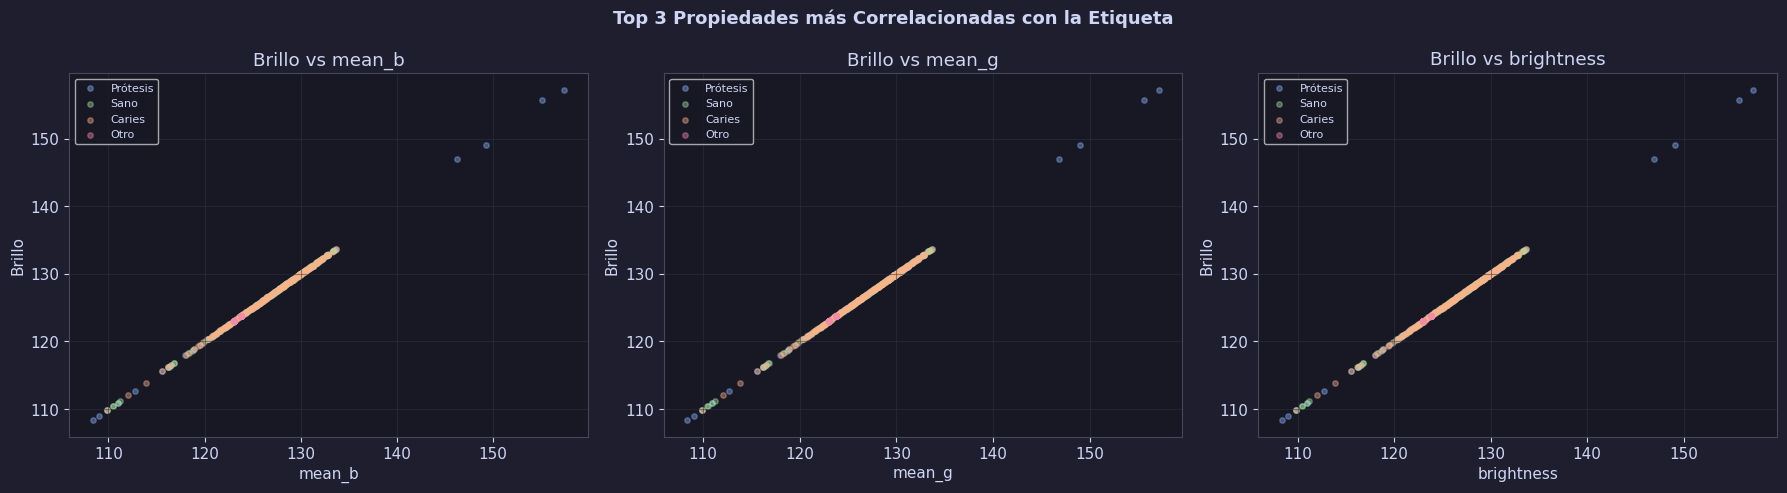

In [14]:
# ─── Scatter plots de las 3 propiedades más correlacionadas ───────────────
if 'label' in corr_df.columns:
    top3 = top_corr.head(3).index.tolist()
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle('Top 3 Propiedades más Correlacionadas con la Etiqueta',
                 fontsize=13, fontweight='bold', color='#cdd6f4')

    for ax, prop in zip(axes, top3):
        for cls in range(4):
            s = df_train_stats[df_train_stats['label'] == cls]
            ax.scatter(s[prop], s['brightness'], color=CLASS_COLORS[cls],
                       label=CLASS_NAMES[cls], alpha=0.4, s=15)
        ax.set_xlabel(prop)
        ax.set_ylabel('Brillo')
        ax.set_title(f'Brillo vs {prop}', color='#cdd6f4')
        ax.legend(fontsize=8)

    plt.tight_layout(); plt.show()

---
## 10. Outliers y Anomalías

=== OUTLIERS DETECTADOS (método IQR) ===
  ✅      brightness:   17 outliers (2.1%)
  ✅        contrast:   12 outliers (1.5%)
  ✅      bytes_size:    0 outliers (0.0%)
  ✅           width:    0 outliers (0.0%)
  ✅          height:    0 outliers (0.0%)


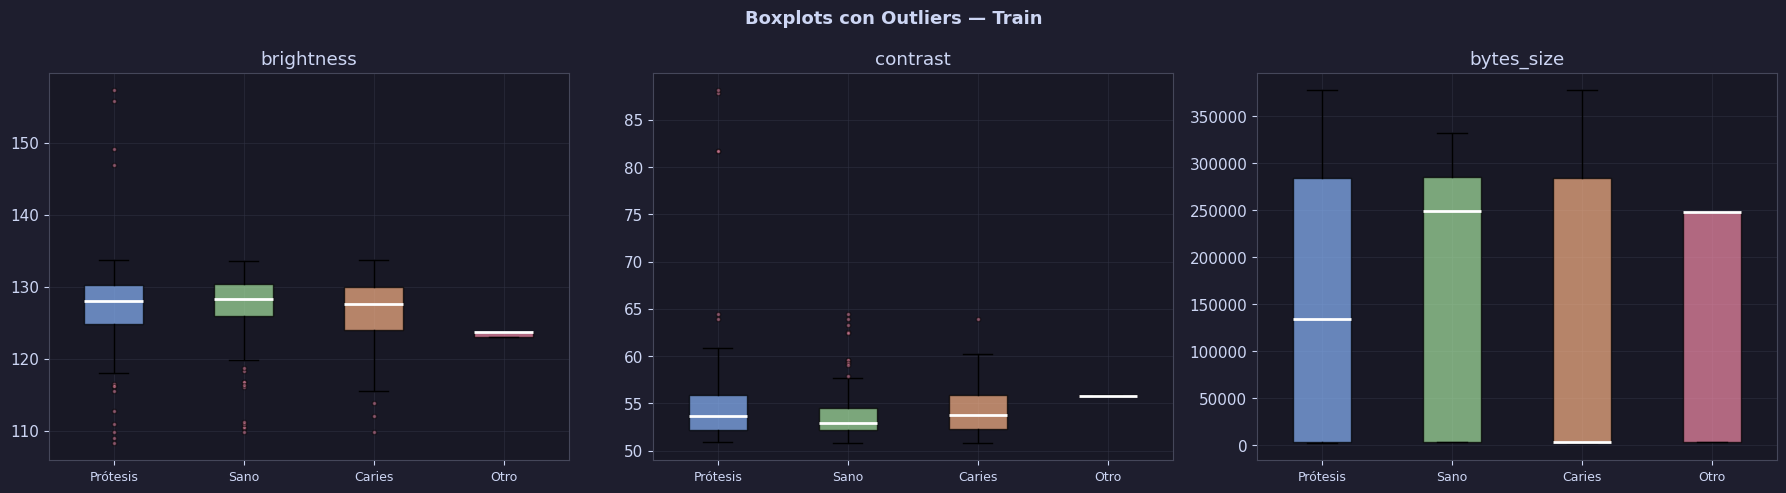

In [15]:
# ─── Detección de outliers (IQR) ──────────────────────────────────────────
outlier_cols = ['brightness', 'contrast', 'bytes_size', 'width', 'height']
outlier_report = {}

for col in outlier_cols:
    if col not in df_train_stats.columns: continue
    Q1, Q3 = df_train_stats[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    out = df_train_stats[(df_train_stats[col] < Q1 - 1.5*IQR) |
                         (df_train_stats[col] > Q3 + 1.5*IQR)]
    outlier_report[col] = len(out)

print('=== OUTLIERS DETECTADOS (método IQR) ===')
for k, v in outlier_report.items():
    pct = v / len(df_train_stats) * 100
    flag = '⚠️' if pct > 5 else '✅'
    print(f'  {flag} {k:>15}: {v:4d} outliers ({pct:.1f}%)')

# ─── Visualización de outliers ────────────────────────────────────────────
n_cols = min(len(outlier_cols), 3)
fig, axes = plt.subplots(1, n_cols, figsize=(n_cols * 6, 5))
fig.suptitle('Boxplots con Outliers — Train', fontsize=13, fontweight='bold', color='#cdd6f4')

for ax, col in zip(axes, outlier_cols[:n_cols]):
    data = [df_train_stats[df_train_stats['label'] == cls][col].values for cls in range(4)]
    bp = ax.boxplot(data, patch_artist=True,
                    medianprops=dict(color='white', linewidth=2),
                    flierprops=dict(marker='o', markersize=3, alpha=0.5,
                                    markerfacecolor='#f38ba8'))
    for patch, color in zip(bp['boxes'], CLASS_COLORS):
        patch.set_facecolor(color); patch.set_alpha(0.7)
    ax.set_title(col, color='#cdd6f4')
    ax.set_xticklabels(CLASS_NAMES, fontsize=9)

plt.tight_layout(); plt.show()

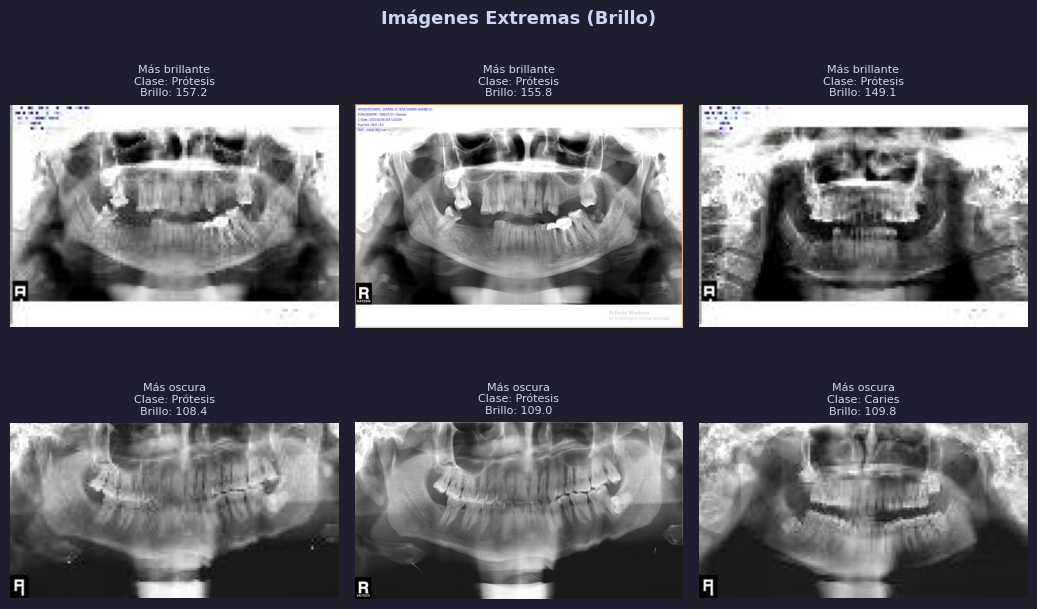

In [16]:
# ─── Imágenes extremas: más brillantes y más oscuras ──────────────────────
n_ext = 3
extremas = pd.concat([
    df_train_stats.nlargest(n_ext, 'brightness'),
    df_train_stats.nsmallest(n_ext, 'brightness'),
])
labels_ext = ['Más brillante'] * n_ext + ['Más oscura'] * n_ext
idx_ext    = list(extremas.index)

fig, axes = plt.subplots(2, n_ext, figsize=(n_ext * 3.5, 7))
fig.suptitle('Imágenes Extremas (Brillo)', fontsize=13, fontweight='bold', color='#cdd6f4')

for i, (idx, lbl) in enumerate(zip(idx_ext, labels_ext)):
    row_ax = i // n_ext; col_ax = i % n_ext
    ax = axes[row_ax][col_ax]
    try:
        img = bytes_to_pil(df_train.iloc[idx]['image'])
        ax.imshow(img)
    except Exception:
        ax.text(0.5, 0.5, 'Error', ha='center', va='center', transform=ax.transAxes)
    row_data = df_train_stats.iloc[idx]
    ax.set_title(f"{lbl}\nClase: {CLASS_NAMES[int(row_data['label'])]}\nBrillo: {row_data['brightness']:.1f}",
                 fontsize=8, color='#cdd6f4')
    ax.axis('off')

plt.tight_layout(); plt.show()

---
## 11. Resumen Ejecutivo

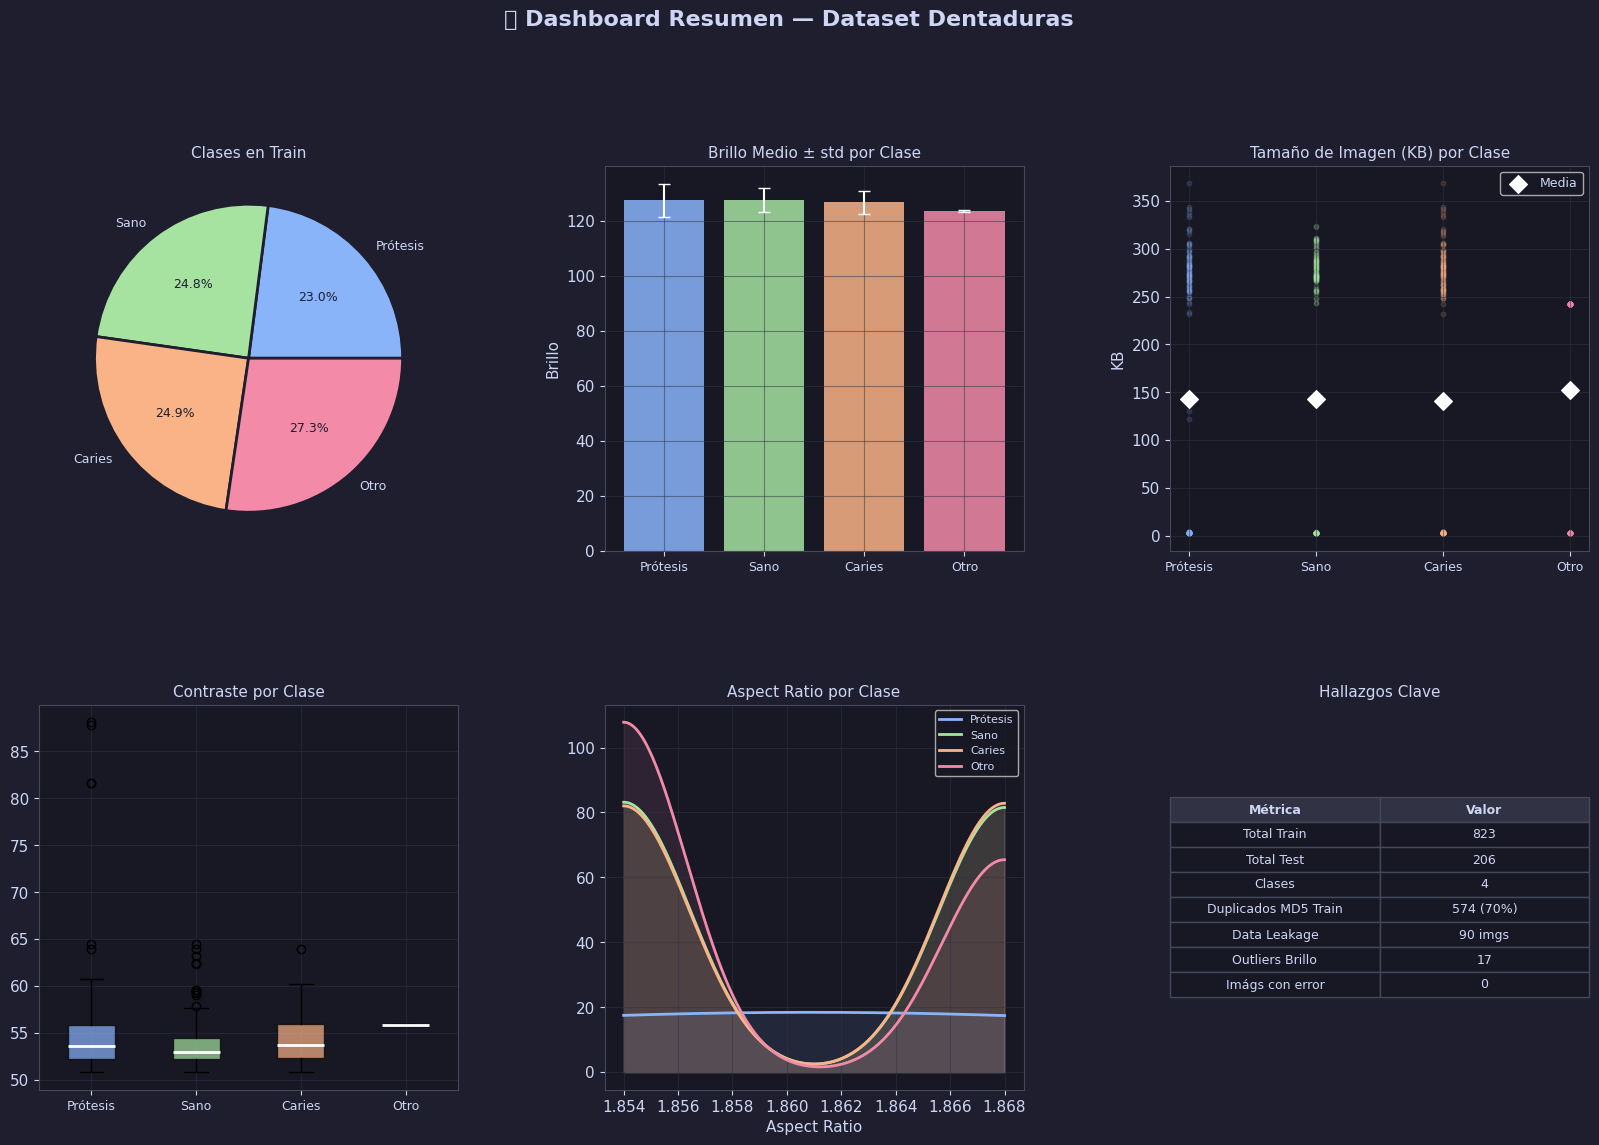

✅ Dashboard guardado como eda_dashboard.png


In [17]:
# ─── Dashboard de resumen ─────────────────────────────────────────────────
fig = plt.figure(figsize=(20, 12))
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)
fig.patch.set_facecolor('#1e1e2e')
fig.suptitle('📊 Dashboard Resumen — Dataset Dentaduras', fontsize=16,
             fontweight='bold', color='#cdd6f4', y=1.01)

# 1. Distribución de clases (Train)
ax1 = fig.add_subplot(gs[0, 0])
counts = df_train['label'].value_counts().sort_index()
wedges, texts, autotexts = ax1.pie(
    counts.values, labels=CLASS_NAMES,
    colors=CLASS_COLORS, autopct='%1.1f%%',
    wedgeprops=dict(edgecolor='#1e1e2e', linewidth=2),
    textprops=dict(color='#cdd6f4', fontsize=9),
)
for at in autotexts: at.set_color('#1e1e2e'); at.set_fontsize(9)
ax1.set_title('Clases en Train', color='#cdd6f4', fontsize=11)

# 2. Brillo medio por clase
ax2 = fig.add_subplot(gs[0, 1])
means = df_train_stats.groupby('label')['brightness'].mean()
stds  = df_train_stats.groupby('label')['brightness'].std()
ax2.bar(range(4), means, yerr=stds, color=CLASS_COLORS, alpha=0.85,
        capsize=4, error_kw={'ecolor': 'white', 'elinewidth': 1.5})
ax2.set_xticks(range(4)); ax2.set_xticklabels(CLASS_NAMES, fontsize=9)
ax2.set_title('Brillo Medio ± std por Clase', color='#cdd6f4', fontsize=11)
ax2.set_ylabel('Brillo')

# 3. Tamaño de bytes por clase
ax3 = fig.add_subplot(gs[0, 2])
for cls in range(4):
    s = df_train_stats[df_train_stats['label'] == cls]['bytes_size'].values / 1024
    ax3.scatter([cls] * len(s), s, color=CLASS_COLORS[cls], alpha=0.15, s=10)
means_b = df_train_stats.groupby('label')['bytes_size'].mean() / 1024
ax3.scatter(range(4), means_b, color='white', zorder=5, s=80, marker='D', label='Media')
ax3.set_xticks(range(4)); ax3.set_xticklabels(CLASS_NAMES, fontsize=9)
ax3.set_title('Tamaño de Imagen (KB) por Clase', color='#cdd6f4', fontsize=11)
ax3.set_ylabel('KB'); ax3.legend(fontsize=9)

# 4. Contraste por clase
ax4 = fig.add_subplot(gs[1, 0])
data_box = [df_train_stats[df_train_stats['label'] == cls]['contrast'].values for cls in range(4)]
bp = ax4.boxplot(data_box, patch_artist=True, medianprops=dict(color='white', linewidth=2))
for patch, color in zip(bp['boxes'], CLASS_COLORS):
    patch.set_facecolor(color); patch.set_alpha(0.7)
ax4.set_xticks(range(1, 5)); ax4.set_xticklabels(CLASS_NAMES, fontsize=9)
ax4.set_title('Contraste por Clase', color='#cdd6f4', fontsize=11)

# 5. Aspect ratio
ax5 = fig.add_subplot(gs[1, 1])
for cls in range(4):
    s = df_train_stats[df_train_stats['label'] == cls]['aspect'].values
    kde = stats.gaussian_kde(s)
    xr = np.linspace(*df_train_stats['aspect'].quantile([0.01, 0.99]), 200)
    ax5.plot(xr, kde(xr), color=CLASS_COLORS[cls], label=CLASS_NAMES[cls], linewidth=2)
    ax5.fill_between(xr, kde(xr), alpha=0.1, color=CLASS_COLORS[cls])
ax5.set_title('Aspect Ratio por Clase', color='#cdd6f4', fontsize=11)
ax5.set_xlabel('Aspect Ratio'); ax5.legend(fontsize=8)

# 6. Tabla de hallazgos clave
ax6 = fig.add_subplot(gs[1, 2])
ax6.axis('off')
hallazgos = [
    ['Métrica',              'Valor'],
    ['Total Train',          f'{len(df_train):,}'],
    ['Total Test',           f'{len(df_test):,}'],
    ['Clases',               '4'],
    ['Duplicados MD5 Train', f'{len(dup_md5_train)} ({len(dup_md5_train)/len(df_train_stats)*100:.0f}%)'],
    ['Data Leakage',         f'{len(leaked)} imgs'],
    ['Outliers Brillo',      f'{outlier_report.get("brightness", 0)}'],
    ['Imágs con error',      f'{len(df_train) - len(df_train_stats)}'],
]
table = ax6.table(cellText=hallazgos[1:], colLabels=hallazgos[0],
                  loc='center', cellLoc='center')
table.auto_set_font_size(False); table.set_fontsize(9)
table.scale(1, 1.5)
for (r, c), cell in table.get_celld().items():
    cell.set_edgecolor('#45475a')
    if r == 0:
        cell.set_facecolor('#313244'); cell.set_text_props(color='#cdd6f4', weight='bold')
    else:
        cell.set_facecolor('#181825'); cell.set_text_props(color='#cdd6f4')
ax6.set_title('Hallazgos Clave', color='#cdd6f4', fontsize=11)

plt.savefig('eda_dashboard.png', dpi=120, bbox_inches='tight', facecolor='#1e1e2e')
plt.show()
print('✅ Dashboard guardado como eda_dashboard.png')

In [18]:
# ─── Conclusiones textuales ───────────────────────────────────────────────
print('=' * 60)
print('CONCLUSIONES DEL ANÁLISIS EXPLORATORIO')
print('=' * 60)

dominant_cls = df_train['label'].value_counts().idxmax()
print(f"""
1. DISTRIBUCIÓN DE CLASES:
   - Clase dominante: {CLASS_NAMES[dominant_cls]} ({df_train['label'].value_counts(normalize=True).max()*100:.1f}%)
   - Chi-cuadrado p-valor={p_chi:.4f} → {'Desbalance significativo ⚠️' if p_chi < 0.05 else 'Sin desbalance significativo ✅'}

2. PROPIEDADES DE IMAGEN:
   - Brillo promedio: {df_train_stats['brightness'].mean():.1f} ± {df_train_stats['brightness'].std():.1f}
   - Contraste promedio: {df_train_stats['contrast'].mean():.1f} ± {df_train_stats['contrast'].std():.1f}
   - Tamaño promedio: {df_train_stats['bytes_size'].mean()/1024:.0f} KB

3. CALIDAD DE DATOS:
   - Duplicados MD5 (Train): {len(dup_md5_train)} ({len(dup_md5_train)/len(df_train_stats)*100:.1f}%)
   - Data Leakage Train-Test: {len(leaked)} {'⚠️ ALERTA' if leaked else '✅ Sin leakage'}
   - Outliers en brillo: {outlier_report.get('brightness', 0)}

4. RECOMENDACIONES:
   {'- 🔴 Aplicar técnicas de balanceo de clases (oversampling / pesos)' if p_chi < 0.05 else ''}
   {'- 🔴 Eliminar duplicados antes de entrenar' if len(dup_md5_train) > 0 else ''}
   {'- 🔴 Revisar leakage: hay imágenes idénticas en train y test' if leaked else ''}
   - Normalizar brillo y contraste (Data Augmentation)
   - Usar augmentation: flips, rotaciones, ajuste de brillo
""")

CONCLUSIONES DEL ANÁLISIS EXPLORATORIO

1. DISTRIBUCIÓN DE CLASES:
   - Clase dominante: Otro (27.3%)
   - Chi-cuadrado p-valor=0.3644 → Sin desbalance significativo ✅

2. PROPIEDADES DE IMAGEN:
   - Brillo promedio: 126.2 ± 4.5
   - Contraste promedio: 54.6 ± 3.0
   - Tamaño promedio: 145 KB

3. CALIDAD DE DATOS:
   - Duplicados MD5 (Train): 574 (69.7%)
   - Data Leakage Train-Test: 90 ⚠️ ALERTA
   - Outliers en brillo: 17

4. RECOMENDACIONES:
   
   - 🔴 Eliminar duplicados antes de entrenar
   - 🔴 Revisar leakage: hay imágenes idénticas en train y test
   - Normalizar brillo y contraste (Data Augmentation)
   - Usar augmentation: flips, rotaciones, ajuste de brillo

